## 10. Gleichungen lösen

[Data Science Playlist auf YouTube](https://www.youtube.com/watch?v=c40z75JnT44&list=PLLBUgWXdTBDg1Qgmwt4jKtVn9BWh5-zgy)
[![Python Data Science](https://apmonitor.com/che263/uploads/Begin_Python/DataScience10.png)](https://www.youtube.com/watch?v=c40z75JnT44&list=PLLBUgWXdTBDg1Qgmwt4jKtVn9BWh5-zgy "Python Data Science")

Gleichungen stehen im Kern der Data Science. Sie verwandeln Daten in handlungsrelevante Informationen, indem sie mathematische Ausdrücke entwickeln, die physikalische Systeme nachbilden. Manche mathematischen Ausdrücke sind einfach und lassen sich der Reihe nach berechnen, zum Beispiel:

$x=1 \quad y=x^2+2x-4$

Die Lösung ist $x=1$ and $y=1+2-4=-1$. Betrachte den Fall, in dem $x$ auch von $y$ abhängt.

$x=y \quad y=x^2+2x-4$

Es gibt zwei Lösungen, die mit der quadratischen Formel $y=\frac{-b\pm\sqrt{b^2-4ac}}{2a}$ berechnet werden.

$0=y^2+(2y-y)-4 \quad y^2+y-4 = 0$ with $a=1$, $b=1$ und $c=-4$.

$y = \frac{-1 \pm \sqrt{17}}{2} = {1.56,-2.56}$

Es gibt zwei Hauptwege, dieses Problem zu lösen.
Die erste Methode ist eine **numerische Lösung**, bei der der Computer mit Versuch-und-Irrtum-Verfahren eine Lösung findet. Numerische Verfahren eignen sich am besten, wenn die Anzahl der Gleichungen groß ist und keine analytische Lösung existiert.
Die zweite Methode ist eine **symbolische Lösung**, die eine exakte Lösung liefert.

![idea](https://apmonitor.com/che263/uploads/Begin_Python/idea.png)

### Numerische Lösung

Großskalige und komplexe Probleme erfordern einen numerischen Lösungsansatz wie mit ``fsolve`` oder ``gekko``. Dafür wird eine Funktion benötigt, die den Gleichungsfehler (Residual) zurückgibt. 
Dieses Residuum ist $f(y)=y^2+y-4$ und ist ungleich null, solange $y$ nicht der korrekten Lösung entspricht. Eine Startschätzung von ``1`` oder ``-2`` führt zu unterschiedlichen Lösungen, weil jeweils in der Nähe der einen bzw. der anderen Lösung gestartet wird.

#### Lösung mit Scipy fsolve

In [1]:
from scipy.optimize import fsolve
def f(y):
    return y**2+y-4
z = fsolve(f,1); print(z)
z = fsolve(f,-2); print(z)

[1.56155281]
[-2.56155281]


![gekko](https://apmonitor.com/che263/uploads/Begin_Python/gekko.png)

**Solution with Python Gekko**

In [2]:
from gekko import GEKKO
m = GEKKO(remote=False)
y = m.Var(1); m.Equation(y**2+y-4==0)
m.solve(disp=False); print(y.value)
y.value = -2
m.solve(disp=False); print(y.value)

[1.5615528128]
[-2.5615528128]


![idea](https://apmonitor.com/che263/uploads/Begin_Python/idea.png)

### Zwei Gleichungen lösen

Das Vorgehen ist gleich, wenn es statt einer zwei Gleichungen gibt.

$y=x^2+2x-4$

$x=y$

Die Funktion gibt das Fehler-Residual für jede Gleichung als Liste zurück. Es werden zwei Startwerte (initial guesses) benötigt. Dieselbe Methode lässt sich auch auf mehr Gleichungen erweitern. Gleichungslöser können Lösungen für Probleme mit tausenden oder Millionen Variablen finden.

**Solution with Scipy fsolve**

In [3]:
from scipy.optimize import fsolve
def f(z):
    x,y = z
    return [x-y,y-x**2-2*x+4]
z = fsolve(f,[1,1]); print(z)
z = fsolve(f,[-2,-2]); print(z)

[1.56155281 1.56155281]
[-2.56155281 -2.56155281]


![gekko](https://apmonitor.com/che263/uploads/Begin_Python/gekko.png)

**Lösung mit Python Gekko**

In [4]:
m = GEKKO(remote=False)
x=m.Var(); y = m.Var(1);
m.Equations([y==x**2+2*x-4, x==y])
m.solve(disp=False)
print(x.value, y.value)

x.value=-2; y.value=-2
m.solve(disp=False)
print(x.value, y.value)

[1.5615528428] [1.5615528428]
[-2.5615528128] [-2.5615528128]


![expert](https://apmonitor.com/che263/uploads/Begin_Python/expert.png)

### Drei Gleichungen lösen

$x^2+y^2+z^2=1$

$x-2y+3z=0.5$

$x+y+z=0$

Löse das Problem mit drei Variablen und drei Gleichungen.


In [5]:
import sympy as sp

# Variablen definieren
x, y, z = sp.symbols('x y z')

# Gleichungen definieren
eq1 = x**2 + y**2 + z**2 - 1
eq2 = x - 2*y + 3*z - 0.5
eq3 = x + y + z

# Gleichungssystem lösen
solution = sp.solve((eq1, eq2, eq3), (x, y, z))

solution

[(-0.789904974719323, 0.215961989887729, 0.573942984831594),
 (0.816220764193007, -0.426488305677203, -0.389732458515804)]

![idea](https://apmonitor.com/che263/uploads/Begin_Python/idea.png)

### Symbolische Lösung

Kleine Probleme können eine analytische Lösung haben, die sich symbolisch ausdrücken lässt.
Ein symbolisches Mathematikpaket in Python ist ``sympy``.
Die Funktion ``display`` steht ebenfalls zur Verfügung, um Gleichungen in Jupyter-Notebooks auszugeben. Dafür ist der Import ``from IPython.display import display`` erforderlich.

In [6]:
from IPython.display import display
import sympy as sym
x = sym.Symbol('x')
y = sym.Symbol('y')
ans = sym.nonlinsolve([x-y, y-x**2-2*x+4], [x,y])
display(ans)

{(-1/2 + sqrt(17)/2, -1/2 + sqrt(17)/2), (-sqrt(17)/2 - 1/2, -sqrt(17)/2 - 1/2)}

![expert](https://apmonitor.com/che263/uploads/Begin_Python/expert.png)

### Drei Gleichungen symbolisch lösen

$x\,y\,z=0$

$x\,y=0$

$x+5\,y+z=0$

Löse das Problem mit drei Variablen und drei Gleichungen symbolisch. Das Problem ist degeneriert (unterbestimmt), daher erscheint eine der Variablen in der Lösung, weil es unendlich viele Lösungen gibt.

In [7]:
import sympy as sp

# Variablen definieren
x, y, z = sp.symbols('x y z')

# Gleichungen definieren
eq1 = x*y*z
eq2 = x*y
eq3 = x + 5*y + z

# Gleichungssystem symbolisch lösen
solution = sp.solve((eq1, eq2, eq3), (x, y, z), dict=True)

solution

[{x: 0, y: -z/5}, {x: -z, y: 0}]

![idea](https://apmonitor.com/che263/uploads/Begin_Python/idea.png)

### Lineare Gleichungen

Lineare Gleichungen lassen sich in Python effizient lösen, z. B. mit `x = np.linalg.solve(A,b)` für $A x = b$ mit Matrix $A$ und den Vektoren $x$ und $b$.

$A = \begin{bmatrix}3 & 2\\ 1 & 2 \end{bmatrix} \quad b = \begin{bmatrix}1 \\ 0 \end{bmatrix}$

In [8]:
import numpy as np
A = np.array([[3,2],[1,2]])
b = np.array([1,0])

x = np.linalg.solve(A,b)
print(x)

[ 0.5  -0.25]


Eine symbolische Lösung für dieses lineare Gleichungssystem ist mit der ``sympy``-Funktion ``linsolve`` möglich.
Ist das Problem linear, wird ``linsolve`` bevorzugt, da es effizienter ist als ``nonlinsolve`` – ``sympy`` kann jedoch beide Arten von Systemen lösen.

In [9]:
import sympy as sym
x, y = sym.symbols('x y')
ans = sym.linsolve([3*x + 2*y - 1, x + 2*y], (x, y))
sym.pprint(ans)

{(1/2, -1/4)}


![idea](https://apmonitor.com/che263/uploads/Begin_Python/idea.png)

### Optimierung

Wenn es mehr Variablen als Gleichungen gibt, ist das Problem unterbestimmt und kann nicht mit einem Gleichungslöser wie fsolve (für lineare oder nichtlineare Probleme) oder linalg.solve (nur für lineare Probleme) gelöst werden. Zusätzliche Informationen sind nötig, um die Wahl der zusätzlichen Variablen zu steuern. Eine Zielfunktion $J(x)$ ist eine Möglichkeit, das Problem so zu spezifizieren, dass eine eindeutige Lösung existiert.

Die Zielfunktion lautet: $x_1 x_4 \left(x_1 + x_2 + x_3\right) + x_3$.
Zwei Nebenbedingungen steuern die Wahl der Variablen: eine Ungleichung $\left(x_1 x_2 x_3 x_4 \ge 25\right)$ und Gleichung $\left(x_1^2 + x_2^2 + x_3^2 + x_4^2 = 40\right)$.
Alle vier Variablen müssen zwischen ``1`` (untere Schranke) und ``5`` (obere Schranke) liegen.

$\quad \min x_1 x_4 \left(x_1 + x_2 + x_3\right) + x_3$

$\quad \mathrm{s.t.} \quad x_1 x_2 x_3 x_4 \ge 25$

$\quad x_1^2 + x_2^2 + x_3^2 + x_4^2 = 40$

$\quad 1\le x_1, x_2, x_3, x_4 \le 5$

mit Startwert (initial guess):

$\quad x_0 = (1,5,5,1)$

Zusätzliche Informationen zur Optimierung sind im [Design Optimization Course](https://apmonitor.com/me575) und im [Design Optimization Book](https://apmonitor.com/me575/index.php/Main/BookChapters) nachzulesen. 
Die erste Lösungsmethode nutzt ``scipy.optimize.minimize``. Die Solver in diesem Paket eignen sich gut für Probleme mittlerer Größe mit Black-Box-Modellen, bei denen die Zielfunktion über einen Funktionsaufruf verfügbar ist.

In [10]:
import numpy as np
from scipy.optimize import minimize

def objective(x):
    return x[0]*x[3]*(x[0]+x[1]+x[2])+x[2]

def constraint1(x):
    return x[0]*x[1]*x[2]*x[3]-25.0

def constraint2(x):
    sum_eq = 40.0
    for i in range(4):
        sum_eq = sum_eq - x[i]**2
    return sum_eq

# Startwerte
n = 4
x0 = np.zeros(n)
x0[0] = 1.0
x0[1] = 5.0
x0[2] = 5.0
x0[3] = 1.0

# optimieren
b = (1.0,5.0)
bnds = (b, b, b, b)
con1 = {'type': 'ineq', 'fun': constraint1} 
con2 = {'type': 'eq', 'fun': constraint2}
cons = ([con1,con2])
solution = minimize(objective,x0,method='SLSQP',\
                    bounds=bnds,constraints=cons)
x = solution.x

# finale Zielfunktion zeigen
print('Final Objective: ' + str(objective(x)))

# Lösung ausgeben
print('Solution')
print('x1 = ' + str(x[0]))
print('x2 = ' + str(x[1]))
print('x3 = ' + str(x[2]))
print('x4 = ' + str(x[3]))

Final Objective: 17.01401724563517
Solution
x1 = 1.0
x2 = 4.742996096883977
x3 = 3.8211546234095715
x4 = 1.379407645075325


![gekko](https://apmonitor.com/che263/uploads/Begin_Python/gekko.png)

### Optimierung mit Gekko

[Python Gekko](https://gekko.readthedocs.io/en/latest/) löst das Problem ebenfalls und verwendet automatische Differenzierung sowie gradientenbasierte Solver wie ``APOPT`` oder ``IPOPT``, um eine Lösung zu finden. Dieses Verfahren eignet sich besser für großskalige Probleme. [Weitere Gekko-Tutorials](https://apmonitor.com/wiki/index.php/Main/GekkoPythonOptimization) zeigen, wie sich andere Arten von Optimierungsproblemen lösen lassen.

In [11]:
from gekko import GEKKO
m = GEKKO(remote=False)

# Variablen initialisieren
x1,x2,x3,x4 = [m.Var(lb=1, ub=5) for i in range(4)]

# Startwerte
x1.value = 1
x2.value = 5
x3.value = 5
x4.value = 1

# Gleichungen
m.Equation(x1*x2*x3*x4>=25)
m.Equation(x1**2+x2**2+x3**2+x4**2==40)

# Zielfunktion
m.Obj(x1*x4*(x1+x2+x3)+x3)

# Lösen
m.solve(disp=False)

# Finale Zielfunktion
print('Final Objective: ' + str(m.options.objfcnval))

# Lösung ausgeben
print('Solution')
print('x1: ' + str(x1.value))
print('x2: ' + str(x2.value))
print('x3: ' + str(x3.value))
print('x4: ' + str(x4.value))

Final Objective: 17.014017127
Solution
x1: [1.000000057]
x2: [4.74299963]
x3: [3.8211500283]
x4: [1.3794081795]


### TCLab-Übung

![expert](https://apmonitor.com/che263/uploads/Begin_Python/expert.png)

### Datenerfassung

![connections](https://apmonitor.com/che263/uploads/Begin_Python/connections.png)

Schalte Heizer 1 auf 100 % und zeichne $T_1$
 alle 10 Sekunden für 3 Minuten auf. Die Daten sollen insgesamt 19 Messpunkte pro Temperatursensor und die Messzeit enthalten, beginnend bei 0. Notiere die Temperaturwerte bei 0, 90 und 180 Sekunden.

In [12]:
import time
import numpy as np
from tclab import TCLab

# Speicherlisten
t_data = []
T1_data = []
T2_data = []

with TCLab() as lab:
    
    # Heizer 1 auf 100 %, Heizer 2 aus
    lab.Q1(100)
    lab.Q2(0)
    
    print("Messung gestartet...\n")
    
    start_time = time.time()
    
    for k in range(19):   # 0 bis 180 s in 10 s Schritten
        
        current_time = time.time() - start_time
        
        T1 = lab.T1
        T2 = lab.T2
        
        t_data.append(current_time)
        T1_data.append(T1)
        T2_data.append(T2)
        
        print(f"t = {current_time:6.1f} s | T1 = {T1:6.2f} °C | T2 = {T2:6.2f} °C")
        
        if k < 18:  # Nach letzter Messung nicht mehr warten
            time.sleep(10)
    
    # Heizer ausschalten
    lab.Q1(0)
    lab.Q2(0)

print("\nMessung abgeschlossen.")

# In numpy-Arrays umwandeln
t_data = np.array(t_data)
T1_data = np.array(T1_data)
T2_data = np.array(T2_data)

# Werte bei 0, 90 und 180 Sekunden ausgeben
indices = [0, 9, 18]

print("\nTemperaturen bei 0, 90 und 180 Sekunden:")
for i in indices:
    print(f"t = {t_data[i]:.1f} s | T1 = {T1_data[i]:.2f} °C | T2 = {T2_data[i]:.2f} °C")

TCLab version 1.0.0
Arduino Leonardo connected on port COM4 at 115200 baud.
TCLab Firmware 2.0.1 Arduino Leonardo/Micro.
Messung gestartet...

t =    0.0 s | T1 =  26.05 °C | T2 =  26.70 °C
t =   10.1 s | T1 =  26.22 °C | T2 =  26.67 °C
t =   20.2 s | T1 =  27.28 °C | T2 =  26.57 °C
t =   30.4 s | T1 =  28.95 °C | T2 =  26.70 °C
t =   40.5 s | T1 =  31.21 °C | T2 =  27.02 °C
t =   50.6 s | T1 =  33.76 °C | T2 =  27.34 °C
t =   60.7 s | T1 =  36.37 °C | T2 =  27.73 °C
t =   70.8 s | T1 =  39.07 °C | T2 =  28.57 °C
t =   80.9 s | T1 =  41.85 °C | T2 =  29.28 °C
t =   91.0 s | T1 =  44.42 °C | T2 =  30.18 °C
t =  101.1 s | T1 =  47.00 °C | T2 =  31.21 °C
t =  111.2 s | T1 =  49.52 °C | T2 =  32.18 °C
t =  121.3 s | T1 =  51.84 °C | T2 =  33.15 °C
t =  131.5 s | T1 =  54.09 °C | T2 =  34.43 °C
t =  141.6 s | T1 =  56.02 °C | T2 =  35.40 °C
t =  151.7 s | T1 =  57.96 °C | T2 =  36.66 °C
t =  161.8 s | T1 =  59.86 °C | T2 =  37.69 °C
t =  171.9 s | T1 =  61.50 °C | T2 =  38.95 °C
t =  182.0 

![expert](https://apmonitor.com/che263/uploads/Begin_Python/expert.png)

### Lineare Gleichungen

Drei Punkte genügen, um ein quadratisches Polynom der Form 
$y =a_0 + a_1 \; x + a_2 \; x^2$ eindeutig festzulegen. Erstelle eine quadratische Regression für $T_2$, indem du nur den ersten, mittleren und letzten Messpunkt verwendest. Angenommen, dies wären die folgenden Messpunkte für $T_2$:

| Zeit (sec) | Temperatur (°C)  |
|------|------|
| 0    | 23.0 |
| 90    | 33.0 |
| 180    | 43.0 |

Löse die lineare Regression als ein System aus drei Gleichungen, indem du die drei Datenpunkte in die Polynomgleichung einsetzt und so drei separate Gleichungen mit $y=T_2$ und $x=time$ erhältst.

$\quad a_0 + a_1 \; 0 + a_2 \; 0^2 = 23.0$

$\quad a_0 + a_1 \; 90 + a_2 \; 90^2 = 33.0$

$\quad a_0 + a_1 \; 180 + a_2 \; 180^2 = 43.0$

In Matrixform werden die linearen Gleichungen zu:

$\quad \begin{bmatrix}1 & 0 & 0 \\ 1 & 90 & 90^2 \\ 1 & 180 & 180^2 \end{bmatrix}\begin{bmatrix}a_0\\a_1\\a_2\end{bmatrix} = \begin{bmatrix}23.0\\33.0\\43.0\end{bmatrix}$

Löse dieses Gleichungssystem für die quadratischen Parameter $a_0$, $a_1$, und $a_2$ mit den zu Beginn der TCLab-Aktivität erfassten Daten. Stelle den quadratischen Fit zusammen mit den Daten dar, um sicherzustellen, dass die Kurve durch die drei angegebenen Datenpunkte verläuft.

a0 = 23.000000, a1 = 0.111111, a2 = -0.000000


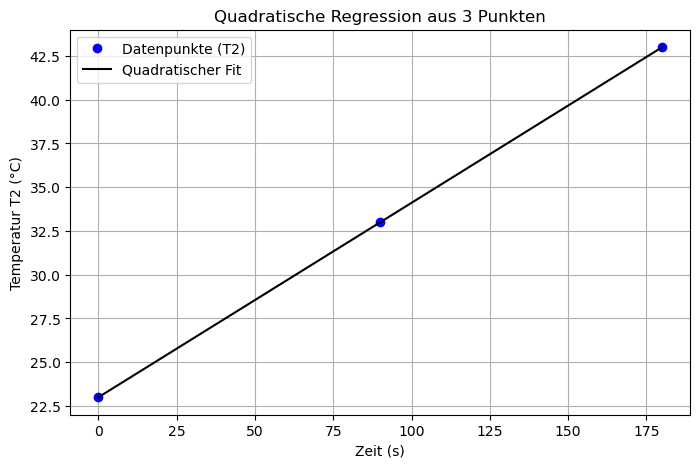

In [13]:
import numpy as np
import matplotlib.pyplot as plt

# Gegebene 3 Datenpunkte (Zeit, T2)
t_pts = np.array([0.0, 90.0, 180.0])
T2_pts = np.array([23.0, 33.0, 43.0])

# Lineares Gleichungssystem für y = a0 + a1*x + a2*x^2
A = np.array([
    [1.0, t_pts[0], t_pts[0]**2],
    [1.0, t_pts[1], t_pts[1]**2],
    [1.0, t_pts[2], t_pts[2]**2]
])

b = T2_pts

# Parameter lösen
a0, a1, a2 = np.linalg.solve(A, b)

print(f"a0 = {a0:.6f}, a1 = {a1:.6f}, a2 = {a2:.6f}")

# Fit-Kurve berechnen
t_fine = np.linspace(0, 180, 300)
T2_fit = a0 + a1*t_fine + a2*(t_fine**2)

# Plot: Datenpunkte + quadratischer Fit
plt.figure(figsize=(8,5))
plt.plot(t_pts, T2_pts, "bo", label="Datenpunkte (T2)")
plt.plot(t_fine, T2_fit, "k-", label="Quadratischer Fit")
plt.xlabel("Zeit (s)")
plt.ylabel("Temperatur T2 (°C)")
plt.title("Quadratische Regression aus 3 Punkten")
plt.grid(True)
plt.legend()
plt.show()

![expert](https://apmonitor.com/che263/uploads/Begin_Python/expert.png)

### Nichtlineare Gleichungen

Fitte die $T_1$-Daten mit nur drei Datenpunkten an eine nichtlineare Korrelation:

$\quad T_1 = a + b \exp{(c \, time)}$

Drei Punkte sind erforderlich, um ein Modell mit drei Parametern eindeutig festzulegen. Wenn mehr als die minimal erforderliche Anzahl an Punkten vorliegt, wird typischerweise eine Kleinste-Quadrate-Regression durchgeführt, um den quadrierten Fehler zwischen gemessenen und vorhergesagten Werten zu minimieren. Für diese Übung verwende nur 3 Punkte (erster, mittlerer, letzter) der $T_1$-Daten. Angenommen, dies wären die folgenden Messpunkte für $T_1$:

| Zeit (sec) | Temperatur (°C)  |
|------|------|
| 0    | 22.0 |
| 90    | 42.0 |
| 180    | 52.0 |

Bestimme die drei Parameter aus den drei Gleichungen, sodass die geforderten Datenpunkte exakt getroffen werden.

$\quad 22.0 = a + b \exp{(c \, 0)}$

$\quad 42.0 = a + b \exp{(c \, 90.3)}$

$\quad 52.0 = a + b \exp{(c \, 180.5)}$

Löse dieses Gleichungssystem für die unbekannten Parameter 
$a$, $b$, und $c$ mit den zu Beginn dieses Notebooks erfassten Daten. Verwende Startwerte $a=100$, $b=-100$, und $c=-0.01$. Stelle den nichtlinearen Fit zusammen mit den Daten dar, um sicherzustellen, dass die Kurve durch die drei angegebenen Datenpunkte verläuft. Füge passende Beschriftungen zum Diagramm hinzu.


a = 62.000000, b = -40.000000, c = -0.007702


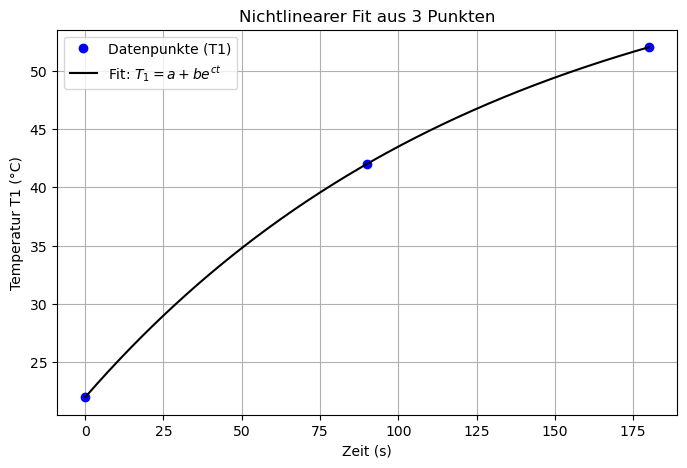

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import fsolve

# 3 Datenpunkte (Zeit, T1)
t_pts = np.array([0.0, 90.0, 180.0])
T1_pts = np.array([22.0, 42.0, 52.0])

# Modell: T1 = a + b * exp(c * time)
def equations(vars_):
    a, b, c = vars_
    return [
        a + b*np.exp(c*t_pts[0]) - T1_pts[0],
        a + b*np.exp(c*t_pts[1]) - T1_pts[1],
        a + b*np.exp(c*t_pts[2]) - T1_pts[2],
    ]

# Startwerte (laut Aufgabe)
x0 = [100.0, -100.0, -0.01]

# Nichtlineares Gleichungssystem lösen
a, b, c = fsolve(equations, x0)

print(f"a = {a:.6f}, b = {b:.6f}, c = {c:.6f}")

# Fit-Kurve berechnen
t_fine = np.linspace(t_pts.min(), t_pts.max(), 300)
T1_fit = a + b*np.exp(c*t_fine)

# Plot: Datenpunkte + Fit
plt.figure(figsize=(8,5))
plt.plot(t_pts, T1_pts, "bo", label="Datenpunkte (T1)")
plt.plot(t_fine, T1_fit, "k-", label=r"Fit: $T_1 = a + b e^{c t}$")
plt.xlabel("Zeit (s)")
plt.ylabel("Temperatur T1 (°C)")
plt.title("Nichtlinearer Fit aus 3 Punkten")
plt.grid(True)
plt.legend()
plt.show()